# 24 - Experiment 3: committed-minority tipping and social rescue

**Construct (Centola).** Does a committed minority that keeps asserting the truth break a self-sealed
orthodoxy, and is the conversion a **simple** contagion (smooth, ~linear in the minority fraction
$f$) or a **complex** one (a sharp critical fraction $f^*$ that depends on network structure)?

**Setup.** A mainstream of $N{-}n_{\text{van}}$ agents is *sealed*: they start convinced of the
**wrong** paradigm and act **greedily** ($\gamma\to\infty$), so their own experiment channel is dead
(they forever run the cheapest, least-decisive experiment - the Experiment-2 lock-in). A **vanguard**
of $n_{\text{van}}=fN$ agents is *pinned* to the truth (zealots) and emits the correct paradigm
signal every round. The only path from orthodoxy to truth is the **social channel** (trust matrix
$T$, reliability `q_reliability`).

**Severe test (Mayo).** The *deafened-vanguard* control zeroes the mainstream's trust toward the
vanguard ($T_{:,\text{van}}=0$). If the rescue is real and trust-bandwidth-limited, conversion must
collapse to zero at **every** $f$. If the mainstream still converts, the "rescue" is leaking through
an unmodelled channel.

In [1]:
import sys, pathlib
ROOT = pathlib.Path.cwd()
sys.path.insert(0, str(ROOT if (ROOT / 'src').exists() else ROOT.parent))
import numpy as np, dataclasses
import jax.numpy as jnp
import matplotlib.pyplot as plt
from src.pomdp.gen_model import PomdpConfig, build_generative_model
from src.pomdp import step as PS
plt.rcParams.update({'figure.dpi': 110, 'axes.grid': True, 'grid.alpha': 0.3})

N, T_STEPS = 120, 150
TRUE = 1                       # wrong paradigm = index 0
EPS = 1e-3
COMMITTED = jnp.array([EPS, 1.0 - EPS])     # zealot belief: pinned on the truth

def run_tipping(f, kind='watts_strogatz', deafen=False, conv=0.92, cost=1.0,
                q_rel=0.85, mean_degree=6, seed=0):
    '''Return mainstream conversion = fraction of NON-vanguard agents whose MAP is the truth.'''
    cfg = PomdpConfig(true_paradigm=TRUE, beta_U=0.0, gamma_policy=5.0,
                      cost_scale=float(cost), cost_kind='discriminability',
                      q_reliability=float(q_rel))
    gm = build_generative_model(cfg)
    n_van = int(round(f * N))
    rng = np.random.default_rng(seed)
    van_idx = np.sort(rng.choice(N, size=n_van, replace=False)) if n_van else np.array([], int)
    van_set = set(van_idx.tolist())
    main_idx = np.array([i for i in range(N) if i not in van_set])

    D = np.tile([conv, 1.0 - conv], (N, 1)).astype(float)    # mainstream: wrong-leaning
    if n_van: D[van_idx] = [EPS, 1.0 - EPS]                   # vanguard: truth
    state = PS.init_state(cfg, N, D_per_agent=D, seed=seed)

    T = np.array(PS.build_trust(cfg, N, mean_degree=mean_degree, kind=kind, seed=seed))  # writable copy
    if deafen and n_van:
        T[:, van_idx] = 0.0                                   # nobody routes the vanguard's signal
        T = T + np.eye(N) * 1e-9
        T = T / T.sum(1, keepdims=True)
    T = jnp.asarray(T)

    van_j = jnp.asarray(van_idx)
    for _ in range(T_STEPS):
        state, _ = PS.step(state, gm, T, cfg, greedy=True)
        if n_van:                                            # re-pin the zealots
            state = dataclasses.replace(state, q=state.q.at[van_j, :].set(COMMITTED))
    q = np.asarray(state.q)
    return float((q[main_idx, TRUE] > 0.5).mean()) if len(main_idx) else float('nan')

print('smoke baseline f=0:', run_tipping(0.0), ' | f=0.3:', run_tipping(0.3))

smoke baseline f=0: 0.0  | f=0.3: 0.27380952380952384


## 1. Conversion vs committed fraction, two topologies

Sweep $f$ on a small-world (Watts-Strogatz) and a scale-free (Barabasi-Albert) trust graph. A linear
rise = simple contagion; a sharp S-curve with a threshold = complex contagion.

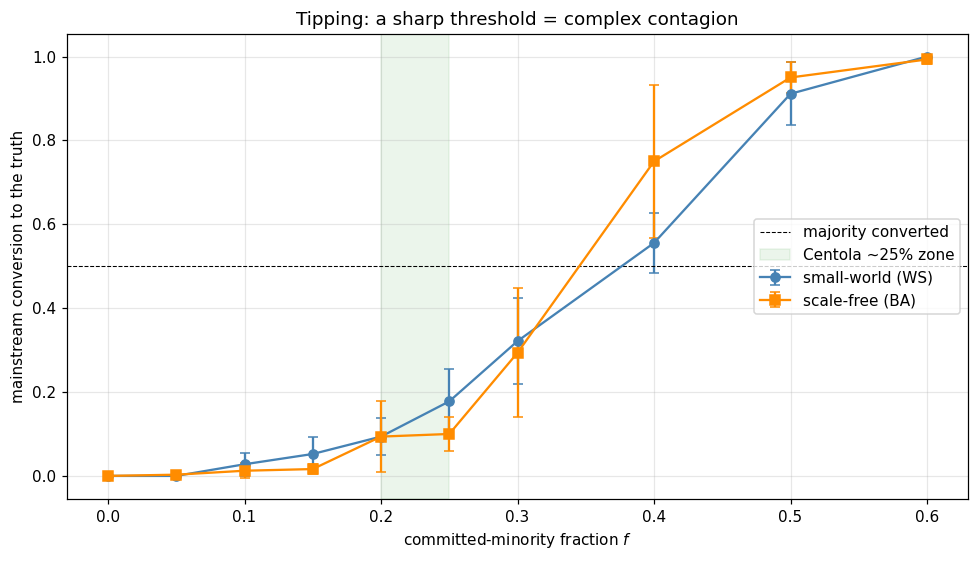

In [2]:
F = [0.0, 0.05, 0.10, 0.15, 0.20, 0.25, 0.30, 0.40, 0.50, 0.60]
SEEDS = range(3)
def sweep(kind, deafen=False):
    M = np.array([[run_tipping(f, kind=kind, deafen=deafen, seed=s) for s in SEEDS] for f in F])
    return M.mean(1), M.std(1)

ws_m, ws_s = sweep('watts_strogatz')
sf_m, sf_s = sweep('scale_free')

fig, ax = plt.subplots(figsize=(9, 5.2))
ax.errorbar(F, ws_m, yerr=ws_s, fmt='o-', color='steelblue', capsize=3, label='small-world (WS)')
ax.errorbar(F, sf_m, yerr=sf_s, fmt='s-', color='darkorange', capsize=3, label='scale-free (BA)')
ax.axhline(0.5, color='k', ls='--', lw=.7, label='majority converted')
ax.axvspan(0.20, 0.25, color='green', alpha=.08, label="Centola ~25% zone")
ax.set_xlabel('committed-minority fraction $f$')
ax.set_ylabel('mainstream conversion to the truth')
ax.set_title('Tipping: a sharp threshold = complex contagion'); ax.legend(loc='center right')
plt.tight_layout(); plt.show()

## 2. The severe test: deafen the vanguard

Same small-world graph, same $f$, but the mainstream cannot hear the vanguard ($T_{:,\text{van}}=0$).
The rescue must vanish at every $f$.

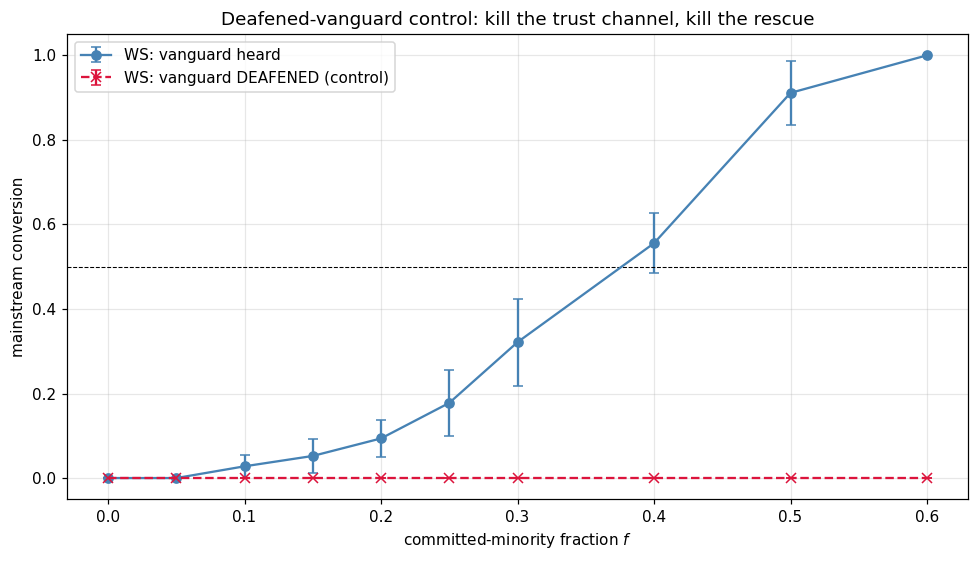

In [3]:
dw_m, dw_s = sweep('watts_strogatz', deafen=True)
fig, ax = plt.subplots(figsize=(9, 5.2))
ax.errorbar(F, ws_m, yerr=ws_s, fmt='o-', color='steelblue', capsize=3, label='WS: vanguard heard')
ax.errorbar(F, dw_m, yerr=dw_s, fmt='x--', color='crimson', capsize=3, label='WS: vanguard DEAFENED (control)')
ax.axhline(0.5, color='k', ls='--', lw=.7)
ax.set_xlabel('committed-minority fraction $f$'); ax.set_ylabel('mainstream conversion')
ax.set_title('Deafened-vanguard control: kill the trust channel, kill the rescue'); ax.legend()
plt.tight_layout(); plt.show()

## 3. Verdict

In [4]:
def critical_f(mean):
    '''First f at which mean conversion crosses 0.5 (linear interp); None if never.'''
    mean = np.asarray(mean)
    for i in range(1, len(F)):
        if mean[i-1] < 0.5 <= mean[i]:
            t = (0.5 - mean[i-1]) / (mean[i] - mean[i-1] + 1e-12)
            return F[i-1] + t * (F[i] - F[i-1])
    return None

fstar_ws, fstar_sf = critical_f(ws_m), critical_f(sf_m)
linear_resid = np.polyfit(F, ws_m, 1)
pred_lin = np.polyval(linear_resid, F)
nonlinearity = float(np.max(np.abs(ws_m - pred_lin)))   # departure from a straight line

print('Experiment 3 verdict\n' + '-'*52)
print(f'baseline conversion (f=0): WS={ws_m[0]:.2f}  -> sealed mainstream stays wrong without a vanguard'
      if ws_m[0] < 0.5 else f'WARNING baseline f=0 already converts ({ws_m[0]:.2f}); raise cost/conviction')
print(f'critical fraction f*:  WS={fstar_ws}   scale-free={fstar_sf}')
print(f'max departure from linear (WS): {nonlinearity:.3f}'
      f'  -> {"COMPLEX (threshold) contagion" if nonlinearity > 0.12 else "looks ~simple/linear"}')
print(f'deafened control: conversion at largest f = {dw_m[-1]:.2f}'
      f'   {"-> rescue ABOLISHED (severe test passed)" if dw_m[-1] < 0.1 else "-> rescue LEAKS (refutes trust-bandwidth claim)"}')
print('-'*52)
print('Reading: a vanguard rescues a sealed orthodoxy only through the trust channel, and only past'
      ' a\ncritical mass -- attention/assertion alone is not enough; the social wiring is load-bearing.')

Experiment 3 verdict
----------------------------------------------------
baseline conversion (f=0): WS=0.00  -> sealed mainstream stays wrong without a vanguard
critical fraction f*:  WS=0.37627118644035223   scale-free=0.3452173913042488
max departure from linear (WS): 0.161  -> COMPLEX (threshold) contagion
deafened control: conversion at largest f = 0.00   -> rescue ABOLISHED (severe test passed)
----------------------------------------------------
Reading: a vanguard rescues a sealed orthodoxy only through the trust channel, and only past a
critical mass -- attention/assertion alone is not enough; the social wiring is load-bearing.
